In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

In [2]:
# Configurações do banco de dados
USER = "lighthouse"
PASSWORD = "lighthouse1"
HOST = "localhost"
PORT = "5430"
DATABASE = "LH_Nautical"
csv_folder_path = "../arquivos/"

#Tabela utilizada
table_name = "orders"

# Cria a conexão com o PostgreSQL
db_url = f"postgresql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"
engine = create_engine(db_url)


df = pd.read_sql_table(table_name, con=engine)


print("\n--Análise estatisticas das colunas numericas--")
print(df.describe())



--Análise estatisticas das colunas numericas--
                 id   customer_id  salesperson_id   location_id  \
count  48998.000000  48998.000000    24867.000000  48998.000000   
mean   25008.051247    999.364688        8.335545      3.494857   
min        1.000000      1.000000        6.000000      1.000000   
25%    12502.250000    501.000000        6.000000      2.000000   
50%    25012.500000    994.000000        9.000000      3.000000   
75%    37504.750000   1497.000000       10.000000      5.000000   
max    50000.000000   2000.000000       10.000000      6.000000   
std    14434.240929    576.835601        1.696963      1.695196   

            subtotal  discount_amount          total  \
count   48998.000000     48998.000000   48998.000000   
mean    29331.903444       626.911367   28704.992077   
min        36.650000         0.000000      32.620000   
25%     13523.870000         0.000000   13171.235000   
50%     26515.300000         0.000000   25917.840000   
75%     4185

Gerando histograma geral...


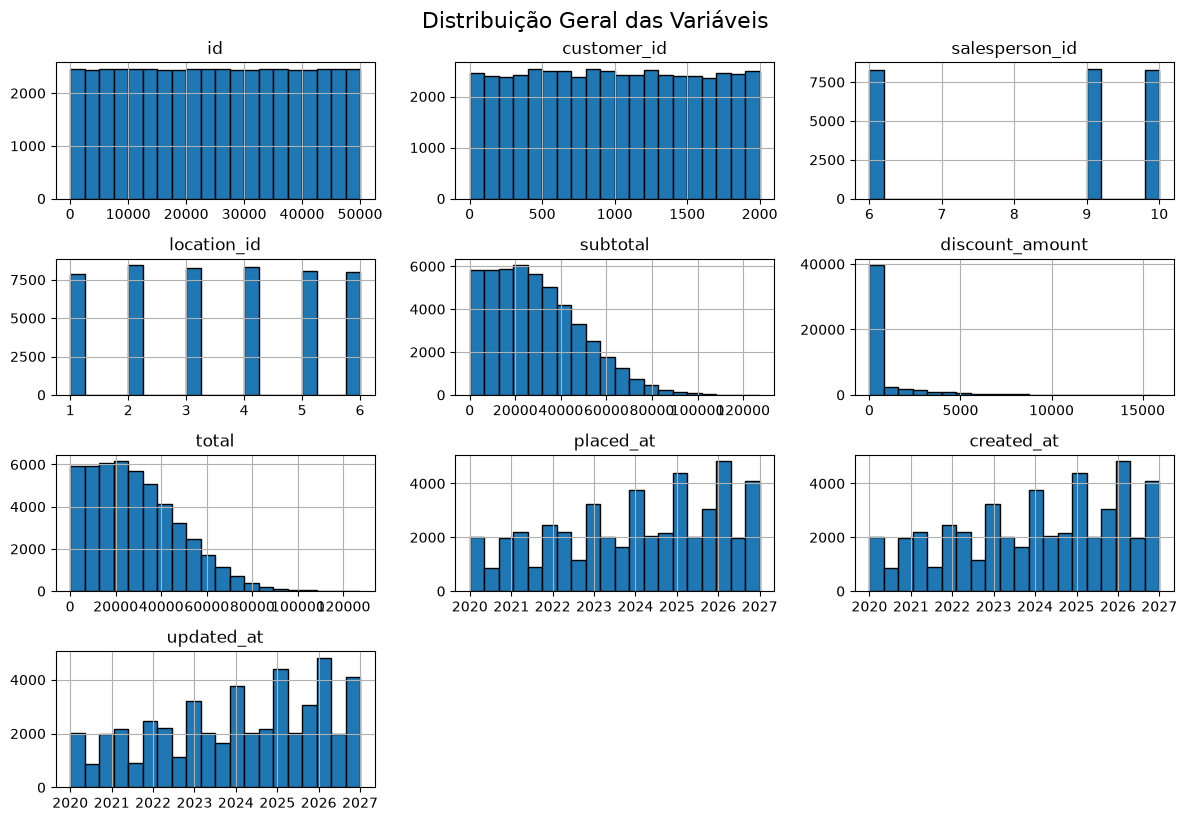

In [3]:
# --Análise dos histogramas das colunas numericas--

print("Gerando histograma geral...")
df.hist(bins=20, figsize=(12, 8), edgecolor="black")
plt.tight_layout()  # Ajusta o espaçamento para não cortar textos
plt.suptitle("Distribuição Geral das Variáveis", y=1.02, fontsize=16)
plt.show()

Analisando a coluna: total


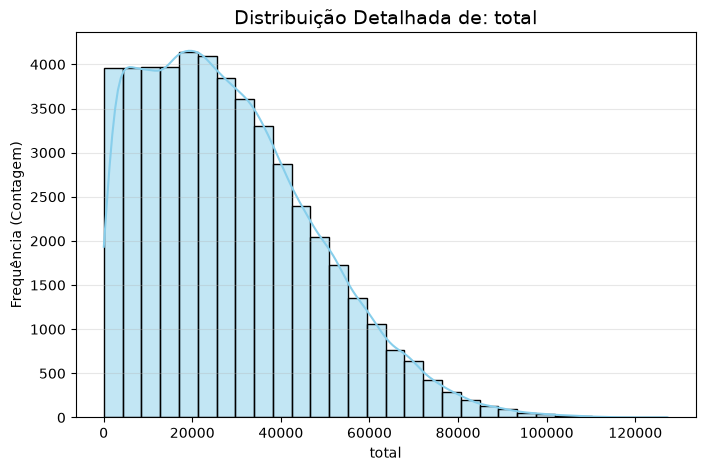

In [4]:
print(f"Analisando a coluna: total")
plt.figure(figsize=(8, 5))

# Cria o histograma com a linha de estimativa de densidade (KDE)
sns.histplot(data=df, x="total", kde=True, bins=30, color="skyblue")

plt.title(f"Distribuição Detalhada de: total", fontsize=14)
plt.xlabel("total")
plt.ylabel("Frequência (Contagem)")
plt.grid(axis="y", alpha=0.3)
plt.show()

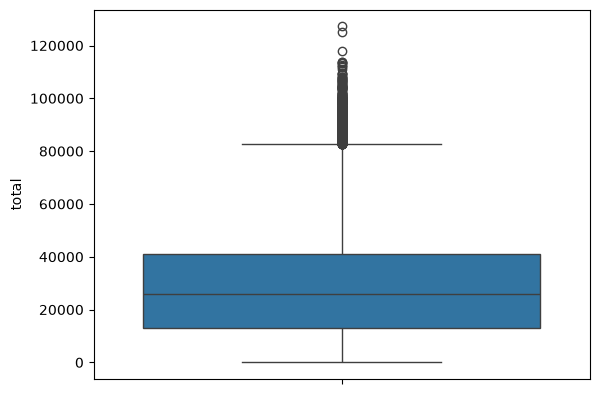

In [5]:
sns.boxplot(y=df['total'])
plt.show()

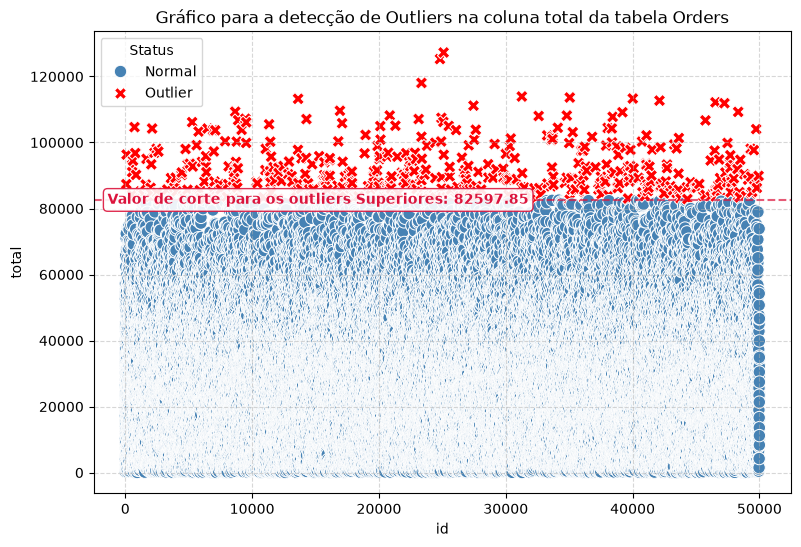

Valor de corte para os outliers Superiores: 82597.85
Quantidade total de outliers:
Inferior 0/48998 (0.0%)
Superior  452/48998 (0.92%)


In [6]:
# 1. Coluna que iremos checar para outliers
target_col = 'total'

# 2. Calcular o IQR para coluna
Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Criar colunas para identifacar se é ou não outlier
df['Is_Outlier'] = (df[target_col] < lower_bound) | (df[target_col] > upper_bound)
df['Status'] = df['Is_Outlier'].map({True: 'Outlier', False: 'Normal'})

# 4. Plotar o grafico com variação de cor dependendo se é ou não outlier
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, 
    x='id', 
    y='total', 
    hue='Status', 
    palette={'Normal': 'steelblue', 'Outlier': 'red'},
    style='Status',  # Gives outliers a different marker shape
    s=80
)

plt.axhline(y=upper_bound, color='crimson', linestyle='--', alpha=0.7, label='Upper Bound')

# Deslocar o texto para que tenha melhor visibilidade
xmin, xmax = plt.xlim()
text_x_position = xmin + (xmax - xmin) * 0.02  # Dar um pequeno offset do lado esquerdo

# Configuração da caixinha de fundo (BBOX)
# 'facecolor' muda a cor do fundo, 'edgecolor' muda a borda e 'boxstyle' arredonda os cantos
box_settings = dict(facecolor='white', edgecolor='crimson', boxstyle='round,pad=0.3', alpha=0.9)

# 8. Escrever os textos com o BACKGROUND ativado (bbox)
plt.text(x=text_x_position, y=upper_bound, s=f'Valor de corte para os outliers Superiores: {upper_bound:.2f}', 
         color='crimson', fontsize=10, fontweight='bold', va='center', bbox=box_settings, zorder=4)

plt.title(f'Gráfico para a detecção de Outliers na coluna {target_col} da tabela Orders')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Limpar as colunas criadas para analise do dataframe
df = df.drop(columns=['Is_Outlier', 'Status'])
print(f"Valor de corte para os outliers Superiores: {upper_bound:.2f}")

# Conta quantos valores estão fora dos limites
total_outliers_lower = (df["total"] < lower_bound).sum()
total_outliers_upper = (df["total"] > upper_bound).sum()

total_lines = len(df)

print(f"Quantidade total de outliers:\nInferior {total_outliers_lower}/{total_lines} ({(total_outliers_lower*100/total_lines).round(2)}%)\nSuperior  {total_outliers_upper}/{total_lines} ({(total_outliers_upper*100/total_lines).round(2)}%)")

# Tem celulas com valores nulos ou inconsistentes?

In [7]:
nulls = df.isna().sum()
total_lines = len(df)
percentage = (nulls / total_lines) * 100


print(nulls.astype(str) + "/" + str(total_lines) + " (" + percentage.round(2).astype(str) + "% nulos)")

id                       0/48998 (0.0% nulos)
order_number             0/48998 (0.0% nulos)
channel                  0/48998 (0.0% nulos)
customer_id              0/48998 (0.0% nulos)
salesperson_id     24131/48998 (49.25% nulos)
location_id              0/48998 (0.0% nulos)
status                   0/48998 (0.0% nulos)
subtotal                 0/48998 (0.0% nulos)
discount_amount          0/48998 (0.0% nulos)
total                    0/48998 (0.0% nulos)
placed_at                0/48998 (0.0% nulos)
created_at               0/48998 (0.0% nulos)
updated_at               0/48998 (0.0% nulos)
dtype: str


In [8]:
df[df['salesperson_id'].isna()].head()

,id,order_number,channel,customer_id,salesperson_id,location_id,status,subtotal,discount_amount,total,placed_at,created_at,updated_at
0,1,SO-000001,ecommerce,1136,NaN,1,paid,323.34,35.57,287.77,2022-09-06 05:37:37,2022-09-06 05:37:37,2022-09-06 05:37:37
3,4,SO-000004,ecommerce,1123,NaN,3,paid,11095.62,665.74,10429.88,2024-03-12 20:39:36,2024-03-12 20:39:36,2024-03-12 20:39:36
5,6,SO-000006,ecommerce,117,NaN,1,paid,52683.82,0.00,52683.82,2026-08-28 17:50:58,2026-08-28 17:50:58,2026-08-28 17:50:58
6,7,SO-000007,ecommerce,489,NaN,1,paid,57270.24,0.00,57270.24,2026-10-29 08:56:37,2026-10-29 08:56:37,2026-10-29 08:56:37
8,10,SO-000010,ecommerce,947,NaN,6,cancelled,26444.39,0.00,26444.39,2022-04-13 16:10:59,2022-04-13 16:10:59,2022-04-13 16:10:59


In [9]:
print(f"Quantidade de linhas com valor NaN, na coluna salesperson_id: {len(df[df['salesperson_id'].isna()])}")
print(f"Quantidade de linhas com valor NaN, na coluna salesperson_id com o channel sendo ecommerce: {len(df[df['salesperson_id'].isna() & (df['channel']=="ecommerce")])}")

Quantidade de linhas com valor NaN, na coluna salesperson_id: 24131
Quantidade de linhas com valor NaN, na coluna salesperson_id com o channel sendo ecommerce: 24131
